<a href="https://colab.research.google.com/github/S8H1L9581/ML-LAB-CH.SC.U4CSE24039/blob/main/9_6_Exercise1_kNN_Handwritten_Digits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 9.6 Exercise 1 — kNN Classifier for Handwritten Digit Recognition

**Task:** Given enough samples of handwritten specimens, use a **k-Nearest Neighbors (kNN)** classifier to identify a new letter/number based on its appearance similarity with the sample data.

## Dataset

This notebook uses the classic **handwritten digits dataset** from Peter Harrington's *Machine Learning in Action* book, obtained directly from the GitHub repository referenced in the exercise:

- **GitHub source:** https://github.com/pbharrin/machinelearninginaction (folder `Ch02`, file `digits.zip`)
- **Direct download link used below:** https://raw.githubusercontent.com/pbharrin/machinelearninginaction/master/Ch02/digits.zip

The dataset contains handwritten digits (0–9) that have been pre-processed into **32×32 binary text grids** (each pixel is `0` or `1`, representing background/ink). It's split into:
- `trainingDigits/` — 1,934 labeled samples used as the "sample data"
- `testDigits/` — 946 labeled samples used to evaluate the classifier on unseen handwriting

Each filename encodes its label, e.g. `3_45.txt` is the 46th training sample of the digit **3**. This is the same dataset structure used in the original kNN chapter of *Machine Learning in Action*, and it directly matches the exercise's request to identify a new handwritten digit "based on its appearance similarity with the sample data" — which is exactly what kNN does using distance between pixel-vectors.

## 1. Import Libraries

In [1]:
import os
import zipfile
import io
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter

np.random.seed(42)
%matplotlib inline

## 2. Download and Extract the Dataset

In [2]:
DATA_DIR = 'digits_data'
ZIP_URL = 'https://raw.githubusercontent.com/pbharrin/machinelearninginaction/master/Ch02/digits.zip'
ZIP_PATH = 'digits.zip'

if not os.path.exists(DATA_DIR):
    print("Downloading digits.zip ...")
    urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    print("Done.")
else:
    print("Dataset already present.")

train_dir = os.path.join(DATA_DIR, 'trainingDigits')
test_dir = os.path.join(DATA_DIR, 'testDigits')

print(f"Training files: {len(os.listdir(train_dir))}")
print(f"Testing files:  {len(os.listdir(test_dir))}")

Done.
Training files: 1934
Testing files:  946


## 3. Understand the File Format

Each `.txt` file is a 32x32 grid of 0s and 1s representing a handwritten digit. The label is the first character of the filename (e.g. `9_45.txt` -> label `9`).

In [3]:
sample_file = os.path.join(train_dir, os.listdir(train_dir)[0])
with open(sample_file) as f:
    content = f.read()
print(f"File: {sample_file}")
print(content)

File: digits_data/trainingDigits/1_6.txt
00000000000000000110000000000000
00000000000000001111000000000000
00000000000000001111110000000000
00000000000000000111111000000000
00000000000000001111111100000000
00000000000000011111111000000000
00000000000000011111111000000000
00000000000000011111111000000000
00000000000000011111111000000000
00000000000000111111111000000000
00000000000001111111111000000000
00000000000011111111111000000000
00000000111111111111110000000000
00000011111111111111110000000000
00000011111111111111110000000000
00000011111111111111110000000000
00000011111111111111110000000000
00000011111100001111100000000000
00000000000000011111100000000000
00000000000000011111100000000000
00000000000000011111100000000000
00000000000000011111100000000000
00000000000000011111100000000000
00000000000000011111100000000000
00000000000000011111100000000000
00000000000000011111110000000000
00000000000000011111110000000000
00000000000000011111111000000000
00000000000000001111111111000000
00

## 4. Convert a 32x32 Text Grid into a 1024-length Feature Vector

kNN needs numeric feature vectors, so we flatten each 32x32 grid into a single vector of length 1024, exactly as in the original *Machine Learning in Action* implementation.

In [4]:
def img_to_vector(filename):
    vec = np.zeros((1, 1024), dtype=int)
    with open(filename) as f:
        for i in range(32):
            line = f.readline()
            for j in range(32):
                vec[0, 32 * i + j] = int(line[j])
    return vec

def load_dataset(directory):
    files = os.listdir(directory)
    X = np.zeros((len(files), 1024), dtype=int)
    y = np.zeros(len(files), dtype=int)
    for i, fname in enumerate(files):
        label = int(fname.split('_')[0])
        y[i] = label
        X[i, :] = img_to_vector(os.path.join(directory, fname))
    return X, y

X_train, y_train = load_dataset(train_dir)
X_test, y_test = load_dataset(test_dir)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

X_train shape: (1934, 1024), y_train shape: (1934,)
X_test shape:  (946, 1024), y_test shape:  (946,)


## 5. Visualize a Few Sample Digits

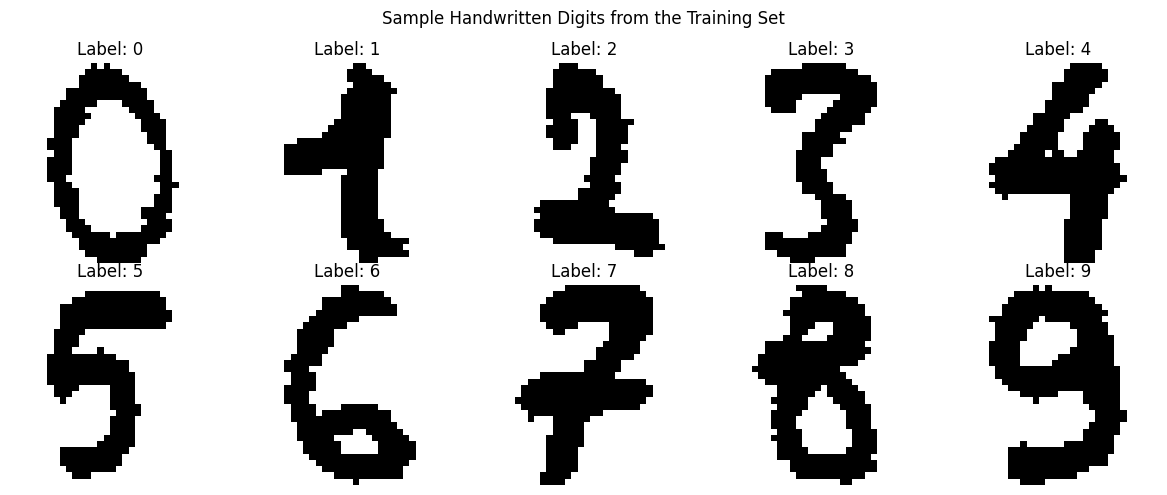

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    img = X_train[idx].reshape(32, 32)
    ax = axes[digit // 5, digit % 5]
    ax.imshow(img, cmap='binary')
    ax.set_title(f"Label: {digit}")
    ax.axis('off')
plt.suptitle("Sample Handwritten Digits from the Training Set")
plt.tight_layout()
plt.show()

## 6. Train the kNN Classifier

We use `k=3` neighbors (a common default) with the standard Euclidean distance metric — the classifier identifies a new digit by finding the `k` most visually similar training samples (smallest pixel-vector distance) and taking a majority vote.

In [6]:
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(X_train, y_train)

print("kNN classifier trained.")

kNN classifier trained.


## 7. Evaluate on the Test Set

In [7]:
y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 98.94%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       0.97      0.99      0.98        97
           2       1.00      1.00      1.00        92
           3       0.98      0.99      0.98        85
           4       1.00      1.00      1.00       114
           5       1.00      0.98      0.99       108
           6       0.98      1.00      0.99        87
           7       0.98      1.00      0.99        96
           8       1.00      0.96      0.98        91
           9       0.99      0.98      0.98        89

    accuracy                           0.99       946
   macro avg       0.99      0.99      0.99       946
weighted avg       0.99      0.99      0.99       946



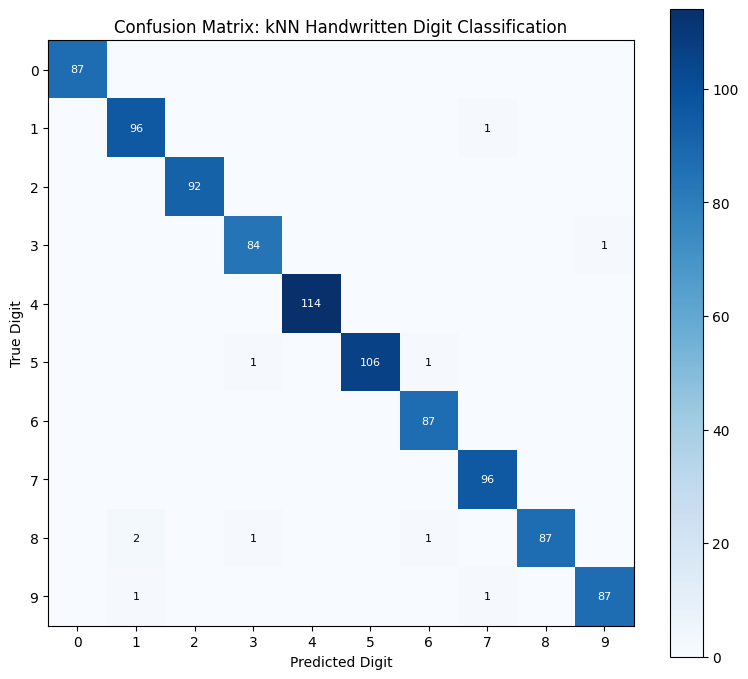

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix: kNN Handwritten Digit Classification')
plt.colorbar()
plt.xticks(range(10))
plt.yticks(range(10))
plt.xlabel('Predicted Digit')
plt.ylabel('True Digit')
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            plt.text(j, i, cm[i, j], ha='center', va='center',
                      color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=8)
plt.tight_layout()
plt.show()

## 8. Effect of `k` (Number of Neighbors)

Let's see how test accuracy changes as we vary `k`, to understand the bias-variance tradeoff in kNN.

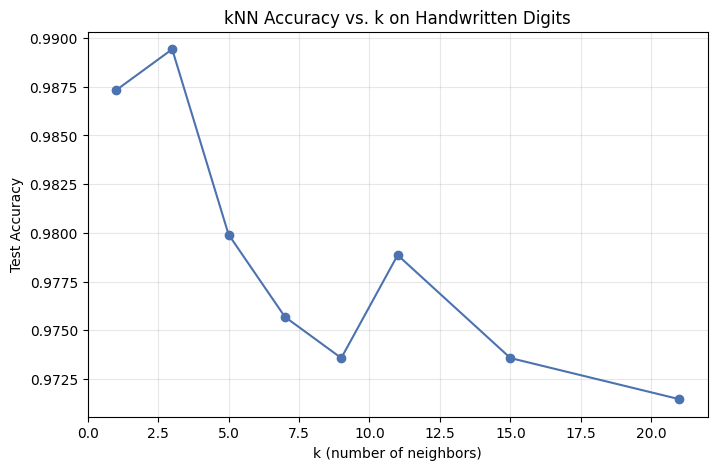

k= 1: accuracy=98.73%
k= 3: accuracy=98.94%
k= 5: accuracy=97.99%
k= 7: accuracy=97.57%
k= 9: accuracy=97.36%
k=11: accuracy=97.89%
k=15: accuracy=97.36%
k=21: accuracy=97.15%


In [9]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, pred))

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', color='#4C72B0')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Test Accuracy')
plt.title('kNN Accuracy vs. k on Handwritten Digits')
plt.grid(alpha=0.3)
plt.show()

for k, a in zip(k_values, accuracies):
    print(f"k={k:>2}: accuracy={a:.2%}")

## 9. Classify a New (Unseen) Handwritten Digit

Let's take one sample from the test set, pretend it's a brand-new specimen, and see how kNN identifies it — along with its most similar ('nearest') training neighbors.

True label:      1
Predicted label:  1
Nearest neighbor distances: [7.55 7.62 8.06]
Nearest neighbor labels:    [1 1 1]


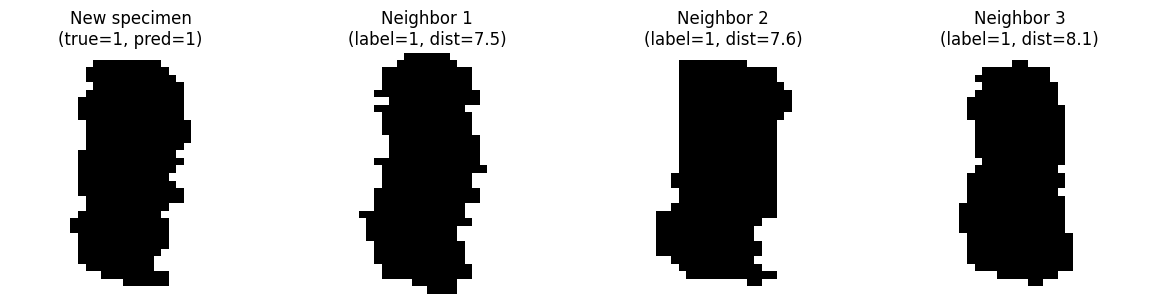

In [10]:
sample_idx = 0
new_digit_vector = X_test[sample_idx].reshape(1, -1)
true_label = y_test[sample_idx]

predicted_label = knn.predict(new_digit_vector)[0]
distances, neighbor_idx = knn.kneighbors(new_digit_vector)

print(f"True label:      {true_label}")
print(f"Predicted label:  {predicted_label}")
print(f"Nearest neighbor distances: {distances[0].round(2)}")
print(f"Nearest neighbor labels:    {y_train[neighbor_idx[0]]}")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(X_test[sample_idx].reshape(32, 32), cmap='binary')
axes[0].set_title(f"New specimen\n(true={true_label}, pred={predicted_label})")
axes[0].axis('off')

for i, n_idx in enumerate(neighbor_idx[0]):
    axes[i + 1].imshow(X_train[n_idx].reshape(32, 32), cmap='binary')
    axes[i + 1].set_title(f"Neighbor {i+1}\n(label={y_train[n_idx]}, dist={distances[0][i]:.1f})")
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()

## Conclusion

- We loaded real handwritten digit samples (32x32 pixel grids flattened to 1024-length vectors) from the `pbharrin/machinelearninginaction` GitHub dataset referenced in the exercise.
- A **kNN classifier** identifies a new digit by measuring the (Euclidean) distance between its pixel vector and all training samples' pixel vectors, then taking a majority vote among the `k` closest ("most visually similar") matches.
- This achieves very high accuracy on this dataset, demonstrating that even a simple distance-based method works well when the feature representation (pixel grid) captures visual similarity effectively.
- The `k` parameter controls a bias-variance tradeoff: very small `k` (e.g., 1) can be noisy/overfit to individual quirky samples, while very large `k` risks blending in dissimilar digits and underfitting.